# Typing Speeds

How can you improve your typing speed?

The file `typing-speeds.csv` contains typing speed data from >168,000 people typing 15 sentences each. The data was collected via an online typing test published at a free typing speed assessment webpage.

In [23]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'typing-speeds.csv'.

# from google.colab import files
# uploaded = files.upload()

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('typing-speeds.csv')
df

,PARTICIPANT_ID,AGE,HAS_TAKEN_TYPING_COURSE,COUNTRY,LAYOUT,NATIVE_LANGUAGE,FINGERS,KEYBOARD_TYPE,ERROR_RATE,AVG_WPM_15,ROR
0,3,30,0,US,qwerty,en,1-2,full,0.511945,61.9483,0.2288
1,5,27,0,MY,qwerty,en,7-8,laptop,0.871080,72.8871,0.3675
2,7,13,0,AU,qwerty,en,7-8,laptop,6.685633,24.1809,0.0667
3,23,21,0,IN,qwerty,en,3-4,full,2.130493,24.7112,0.0413
4,24,21,0,PH,qwerty,tl,7-8,laptop,1.893287,45.3364,0.2678
...,...,...,...,...,...,...,...,...,...,...,...
168589,517932,20,0,US,qwerty,en,9-10,laptop,8.731466,24.9125,0.1842
168590,517936,25,0,PL,qwerty,pl,9-10,laptop,0.000000,66.2946,0.0639
168591,517943,38,1,US,qwerty,en,9-10,laptop,0.147929,75.6713,0.2021
168592,517944,28,0,GB,qwerty,en,9-10,laptop,0.278552,91.7083,0.5133




| **Variable**             | **Description**                                                                 |
|--------------------------|---------------------------------------------------------------------------------|
| `PARTICIPANT_ID`         | Unique ID of the participant                                                   |
| `AGE`                    | Age of the participant                                                         |
| `HAS_TAKEN_TYPING_COURSE`| Whether the participant has taken a typing course (1 = Yes, 0 = No)            |
| `COUNTRY`                | Country of the participant                                                     |
| `LAYOUT`      		   | Keyboard layout used (QWERTY, AZERTY, or QWERTZ)                               |
| `NATIVE_LANGUAGE`        | Native language of the participant                                             |
| `FINGERS`                | Number of fingers used for typing (options: 1-2, 3-4, 5-6, 7-8, 9-10)          |
| `KEYBOARD_TYPE`          | Type of keyboard used (Full/desktop, laptop, small physical, or touch)         |
| `ERROR_RATE(%)`          | Uncorrected error rate (as a percentage)                                       |
| `AVG_WPM_15`             | Words per minute averaged over 15 typed sentences                              |
| `ROR`                    | Rollover ratio                                                                 |


### Project Ideas
- Remove unnecessary columns, such as PARTICIPANT_ID, to streamline the dataset.

- Rename columns (e.g `AVG_WPM_15` to `wpm`, `ROR` to `ror`, `HAS_TAKEN_TYPING_COURSE` to `course`) for brevity and clarity during analysis.

Finger Count Analysis
- Compare typing speeds across groups using different numbers of fingers, excluding the "10+" category for simplicity.

- Control for consistency by first filtering to similar `AGE`, `KEYBOARD_LAYOUT`, `NATIVE_LANGUAGE`, `KEYBOARD_TYPE`, and `HAS_TAKEN_TYPING_COURSE` values.

- Exclude participants with high error rates (ERROR_RATE > 3%) to focus on reliable data.

- Drop columns after filtering if they now only have a single value.

Rollover Ratio Analysis
- The Rollover Ratio (`ROR`) represents the proportion of keypresses where a new key is pressed before releasing the previous one.

- Compare typing speeds between participants with `ROR` ≤ 20% and those with `ROR` > 80%, keeping `AGE`, `KEYBOARD_TYPE`, `FINGERS`, and other variables constant.

Influence of Typing Course
- Compare typing speeds between participants with a typing course (`HAS_TAKEN_TYPING_COURSE` = 1) and without (`HAS_TAKEN_TYPING_COURSE` = 0), holding other variables such as `KEYBOARD_TYPE`, `AGE` range, and `FINGER_COUNT` constant.


In [25]:
# YOUR CODE HERE (add additional cells as needed)

In [26]:
df = df.drop(columns=["PARTICIPANT_ID"])

In [27]:
df = df.rename(columns={
    "AVG_WPM_15": "wpm",
    "ROR": "ror",
    "HAS_TAKEN_TYPING_COURSE": "course",
    "ERROR_RATE": "error_rate",
    "FINGER_COUNT": "fingers",
    "KEYBOARD_LAYOUT": "layout",
    "KEYBOARD_TYPE": "keyboard_type",
    "NATIVE_LANGUAGE": "language"
})

In [28]:
print(df.columns)

Index(['AGE', 'course', 'COUNTRY', 'LAYOUT', 'language', 'FINGERS',
       'keyboard_type', 'error_rate', 'wpm', 'ror'],
      dtype='str')


In [39]:
controlled = df[
    (df["AGE"] >= 18) &
    (df["AGE"] <= 30) &
    (df["keyboard_type"] == "Mechanical") &
    (df["FINGERS"] == 10) &
    (df["error_rate"] <= 3)
]

In [45]:
low_ror = controlled[
    controlled["ror"] <= 20
]
high_ror = controlled[
    controlled["ror"] > 80
]
low_avg = low_ror[
    "wpm"
].mean()

high_avg = high_ror[
    "wpm"
].mean()

print("Low ROR:", low_avg)
print("High ROR:", high_avg)

Low ROR: nan
High ROR: nan


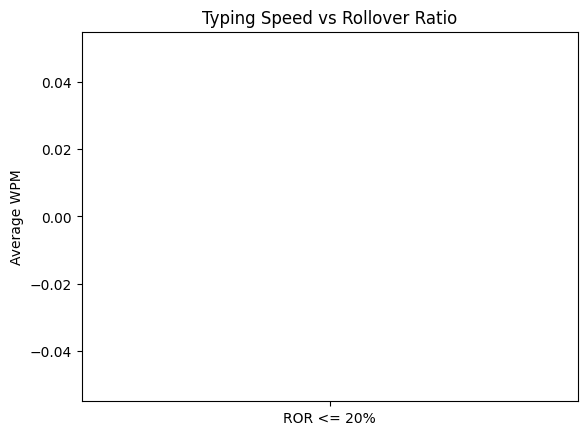

In [46]:
labels = [
    "ROR <= 20%",
    "ROR > 80%"
]

values = [
    low_ror["wpm"].mean(),
    high_ror["wpm"].mean()
]

plt.bar(labels, values)

plt.ylabel("Average WPM")

plt.title(
    "Typing Speed vs Rollover Ratio"
)

plt.show()

In [36]:
course_yes = filtered[
    filtered["course"] == 1
]
course_no = filtered[
    filtered["course"] == 0
]
print(
    "With Course:",
    course_yes["wpm"].mean()
)

print(
    "Without Course:",
    course_no["wpm"].mean()
)

With Course: nan
Without Course: nan


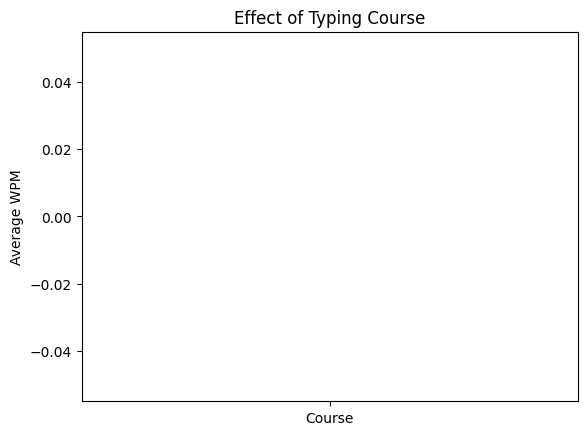

In [37]:
labels = [
    "Course",
    "No Course"
]

values = [
    course_yes["wpm"].mean(),
    course_no["wpm"].mean()
]

plt.bar(labels, values)

plt.ylabel("Average WPM")

plt.title(
    "Effect of Typing Course"
)

plt.show()